# Osteoporosis Risk Prediction

The aim of this project is to predict the risk of osteoporosis in patients using a dataset of patients' medical records. Osteoporosis is a condition that weakens bones, making them fragile and more likely to break. It develops slowly over several years and is often only diagnosed when a minor fall or sudden impact causes a bone fracture. The condition is more common in older people, particularly.

#### About the dataset

The dataset offers comprehensive information on health factors influencing osteoporosis development, including demographic details, lifestyle choices, medical history, and bone health indicators. It aims to facilitate research in osteoporosis prediction, enabling machine learning models to identify individuals at risk. Analyzing factors like age, gender, hormonal changes, and lifestyle habits can help improve osteoporosis management and prevention strategies.

#### Data Dictionary

| Column                               | Description                                                              |
| ------------------------------------ | ------------------------------------------------------------------------ |
| **ID**                               | Unique identifier for each patient                                       |
| **Age**                              | Age of the patient                                                       |
| **Gender**                           | Gender of the patient                                                    |
| **Hormonal Changes**                 | Whether the patient has undergone hormonal changes                       |
| **Family History with Osteoporosis** | Whether the patient has a family history of osteoporosis                 |
| **Race/Ethnicity**                   | Race or ethnicity of the patient                                         |
| **Body Weight**                      | Weight details of the patient                                            |
| **Calcium**                          | Calcium levels in the patient's body                                     |
| **Vitamin D**                        | Vitamin D levels in the patient's body                                   |
| **Physical Activity**                | Physical activity details of the patient                                 |
| **Smoking**                          | Whether the patient smokes                                               |
| **Alcohol Consumption**              | Whether the patient consumes alcohol                                     |
| **Medical Conditions**               | Medical conditions of the patient                                        |
| **Medication**                       | Medication details of the patient                                        |
| **Prior Fracture**                   | Whether the patient has had a prior fracture                             |
| **Osteoporosis**                     | Target variable indicating whether the patient has osteoporosis (Yes/No) |


##### Potential analysis in this project


* Predictive Modeling: Develop machine learning models to predict the probability of osteoporosis based on the provided features. This analysis is crucial for identifying individuals at risk of osteoporosis, enabling early intervention and prevention strategies.

* Feature Importance Analysis: Determine the importance of each feature in predicting osteoporosis risk. Understanding which factors have the most significant impact on osteoporosis risk can provide insights into the underlying mechanisms and guide targeted interventions.

* Correlation Analysis: Examine correlations between different features and osteoporosis risk. Identifying strong correlations can help identify potential risk factors or associations that may warrant further investigation or intervention.

* Subgroup Analysis: Analyze how osteoporosis risk varies across different subgroups based on demographics, lifestyle factors, or medical history. Understanding how risk factors interact within different population groups can inform personalized approaches to osteoporosis prevention and management.

* Model Interpretation: Interpret the trained models to understand how different features contribute to osteoporosis risk prediction. This analysis can provide insights into the underlying relationships between variables and help healthcare professionals make informed decisions regarding patient care and management strategies.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize

In [2]:
#load the dataset
orp_data = pd.read_csv(r"C:\Users\shobi\Documents\GitHub\Osteoporosis-Risk-Prediction\data\osteoporosis.csv")
orp_data

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,104866,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,101999,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,106567,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,102316,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,101944,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1953,106130,19,Female,Normal,Yes,African American,Normal,Adequate,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,NaN,Yes,0
1954,106463,23,Female,Postmenopausal,Yes,Caucasian,Underweight,Low,Insufficient,Active,No,NaN,NaN,Corticosteroids,No,0
1955,103142,34,Female,Postmenopausal,No,African American,Underweight,Low,Sufficient,Sedentary,No,NaN,Hyperthyroidism,NaN,No,0
1956,105187,25,Male,Postmenopausal,No,African American,Normal,Low,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,Yes,0


### Data preprocessing part - 1

In [3]:
# shape dataset
orp_data.shape

(1958, 16)

In [4]:
#info of dataset
orp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-null   object
 8   Vitamin D Intake     1958 non-null   object
 9   Physical Activity    1958 non-null   object
 10  Smoking              1958 non-null   object
 11  Alcohol Consumption  970 non-null    object
 12  Medical Conditions   1311 non-null   object
 13  Medications          973 non-null    object
 14  Prior Fractures      1958 non-null   object
 15  Osteoporosis         1958 non-null   int64 
dtypes: int

In [5]:
#missing values
orp_data.isnull().sum()

Id                       0
Age                      0
Gender                   0
Hormonal Changes         0
Family History           0
Race/Ethnicity           0
Body Weight              0
Calcium Intake           0
Vitamin D Intake         0
Physical Activity        0
Smoking                  0
Alcohol Consumption    988
Medical Conditions     647
Medications            985
Prior Fractures          0
Osteoporosis             0
dtype: int64

Few columns have missing values, so before proceeding with the analysis, I will first handle the missing values in the dataset.

In [6]:
#columns with missing values
columns_with_missing_values = orp_data.columns[orp_data.isnull().any()]

print("Missing values percentage")

for column in columns_with_missing_values:
    print(column,":",orp_data[column].isnull().sum()/orp_data.shape[0]*100)

Missing values percentage
Alcohol Consumption : 50.45965270684371
Medical Conditions : 33.04392236976506
Medications : 50.30643513789581


Alcohol Consumption and Medications columns have more than 50% missing values, I will be replacing these missing values with "None" as it is possible that the patient does not consume alcohol or take any medications. The same goes for the Medical Conditions column.

However, the columns with more than 50% missing values might not be much useful for the analysis, but still I am keeping them for the remaining 50% of the data.

In [7]:
#replace the missing values with'None'
orp_data.fillna("None",inplace=True)

#after None added check missing values
orp_data.isnull().sum()

Id                     0
Age                    0
Gender                 0
Hormonal Changes       0
Family History         0
Race/Ethnicity         0
Body Weight            0
Calcium Intake         0
Vitamin D Intake       0
Physical Activity      0
Smoking                0
Alcohol Consumption    0
Medical Conditions     0
Medications            0
Prior Fractures        0
Osteoporosis           0
dtype: int64

In [8]:
#duplicated values
orp_data.duplicated().sum()

np.int64(0)

In [9]:
#id the column is not useful so drop the column
orp_data = orp_data.drop(['Id'],axis=1)

The column ID is an identifier and irrelevant for the analysis, so I will drop this column

In [10]:
# values in categorical columns
categorical_columns = orp_data.select_dtypes(include=['object']).columns

for column1 in categorical_columns:
    print(orp_data[column1].value_counts().reset_index().to_string())

   Gender  count
0    Male    992
1  Female    966
  Hormonal Changes  count
0           Normal    981
1   Postmenopausal    977
  Family History  count
0             No    998
1            Yes    960
     Race/Ethnicity  count
0  African American    681
1         Caucasian    646
2             Asian    631
   Body Weight  count
0       Normal   1027
1  Underweight    931
  Calcium Intake  count
0            Low   1004
1       Adequate    954
  Vitamin D Intake  count
0       Sufficient   1011
1     Insufficient    947
  Physical Activity  count
0            Active   1021
1         Sedentary    937
  Smoking  count
0     Yes    982
1      No    976
  Alcohol Consumption  count
0                None    988
1            Moderate    970
     Medical Conditions  count
0       Hyperthyroidism    678
1                  None    647
2  Rheumatoid Arthritis    633
       Medications  count
0             None    985
1  Corticosteroids    973
  Prior Fractures  count
0             Yes    983
1   

In [11]:
#describe
orp_data.describe()

,Age,Osteoporosis
count,1958.000000,1958.000000
mean,39.101124,0.500000
std,21.355424,0.500128
min,18.000000,0.000000
25%,21.000000,0.000000
50%,32.000000,0.500000
75%,53.000000,1.000000
max,90.000000,1.000000


In [12]:
# data cleaned
orp_data.head()

,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,None,None,None,Yes,1
2,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,None,Rheumatoid Arthritis,Corticosteroids,No,1
4,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,None,Rheumatoid Arthritis,None,Yes,1


### Exploratory Data Analysis

In the exploratory data analysis, I will be looking at the distribution of the data across all the variables and relationships between the variables and the target variable. For this I will be plotting the dataset variables in different graphs and draw out insights from them

Text(0.5, 1.0, 'Osteoporosis')

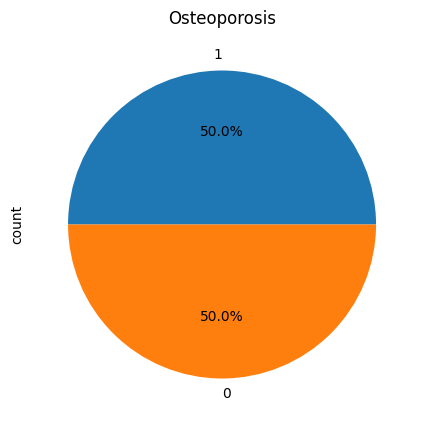

In [13]:
#pie chart for target variable
plt.figure(figsize=(5,5))
orp_data['Osteoporosis'].value_counts().plot.pie(autopct = '%1.1f%%').set_title("Osteoporosis")

The above pie chart shows that the dataset is perfectly balanced with 50% of the patients having osteoporosis and 50% not having osteoporosis, which means that the dataset is not biased towards any class.

#### Age and Osteoporosis

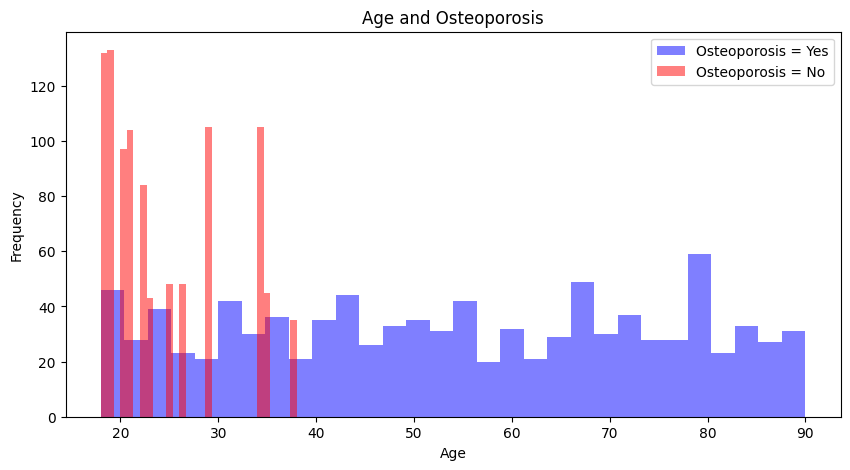

In [14]:
#two layer histogram for the aga and Osteoporosis
plt.figure(figsize=(10,5))
orp_data[orp_data['Osteoporosis']==1]['Age'].plot.hist(bins = 30,alpha=0.5,color= 'blue',label='Osteoporosis = Yes')
orp_data[orp_data['Osteoporosis']==0]['Age'].plot.hist(bins=30,alpha= 0.5,color='red',label='Osteoporosis = No')

#legend and title
plt.legend()
plt.xlabel("Age")
plt.title('Age and Osteoporosis')
plt.show()

This graph shows relation between the risk of osteoporosis and the age of the patient. In the graph we can see that that there is significant risk of osteoporosis in patients of all ages but patients between the ages 20 to 40 have significantly much lower risk of osteoporosis. This highlights that fact that younger patients are less likely to have osteoporosis.

#### Gender and Osteoporosis

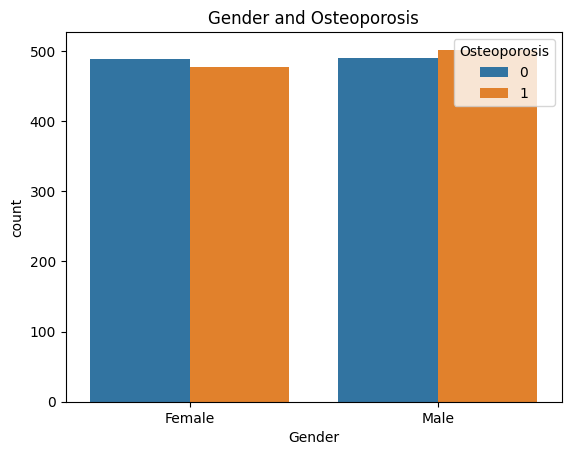

In [15]:
#countplot for Gender and Osteoporosis
sns.countplot(x='Gender',data=orp_data, hue='Osteoporosis')
plt.title("Gender and Osteoporosis")
plt.show()

In this graph, we can visualize the relationship between gender and the risk of osteoporosis. The graph shows that there is no concrete relationship between gender and the risk of osteoporosis, however, according to the numbers in the dataset, the males tend to have slightly higher number of osteoporosis cases than females, but the difference is not significant. Therefore, gender could be a weak predictor for osteoporosis.

#### Hormonal Changes and Osteoporosis

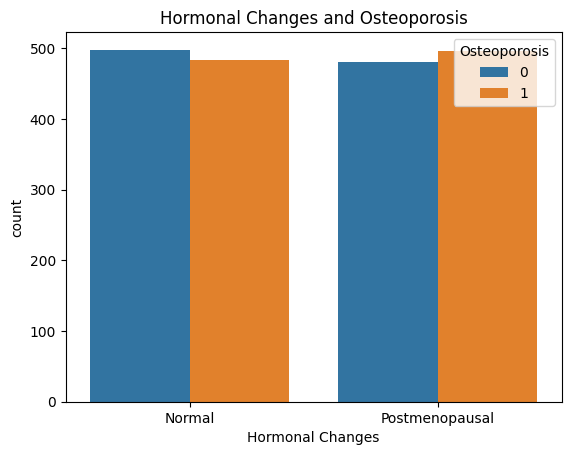

In [16]:
# countplot for Hormonal Changes and Osteoporosis
sns.countplot(x='Hormonal Changes',data=orp_data,hue='Osteoporosis')
plt.title('Hormonal Changes and Osteoporosis')
plt.show()

_Note: Here Postmenopausal is not only for females, but it also reflects the cap on testosterone production in males, therefore for both genders, the hormonal changes are termed as postmenopausal._

The graph shows that patients who have undergone hormonal changes have a higher risk of osteoporosis than those who have not undergone hormonal changes. This indicates that hormonal changes can be a significant risk factor for osteoporosis. This highlights that our hormones contribute in making our bones strong.

#### Family History and Osteoporosis

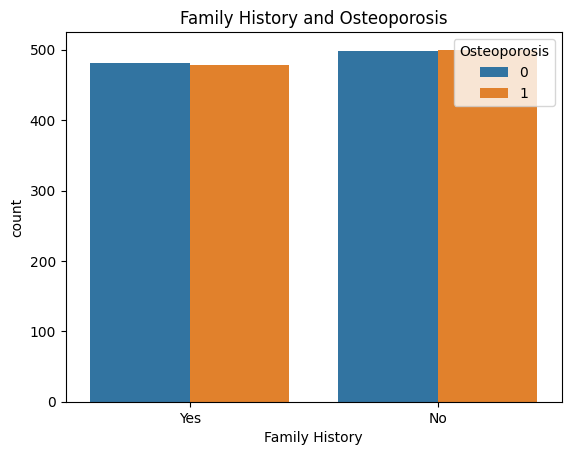

In [17]:
#countplot for Family History and Osteoporosis
sns.countplot(x='Family History',data=orp_data,hue='Osteoporosis')
plt.title('Family History and Osteoporosis')
plt.show()

#### Race/Ethnicity and Osteoporosis

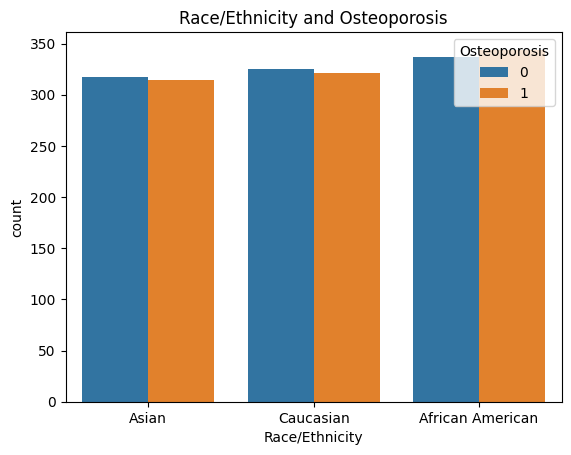

In [18]:
sns.countplot(x='Race/Ethnicity',data = orp_data, hue='Osteoporosis')
plt.title("Race/Ethnicity and Osteoporosis")
plt.xlabel('Race/Ethnicity')
plt.show()

This graph shows the relationship between Race/Ethnicity and the risk of osteoporosis. The graph shows that the risk of osteoporosis is almost similar with no concrete relationship between the race and risk of osteoporosis.

#### Body Weight and Osteoporosis

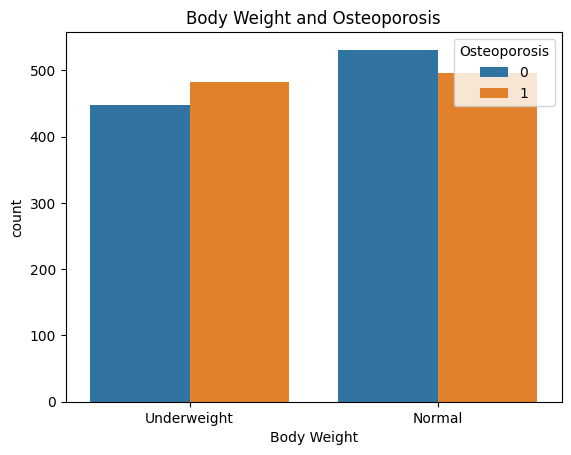

In [19]:
sns.countplot(x='Body Weight',data=orp_data,hue='Osteoporosis')
plt.title("Body Weight and Osteoporosis")
plt.xlabel("Body Weight")
plt.show()

Body weight is an important factor in determining the risk of osteoporosis. The graph shows that patients with lower body weight have a higher risk of osteoporosis than those with higher body weight. This indicates that body weight can be a significant risk factor for osteoporosis. This highlights that our body weight contributes in making our bones strong.

#### Nutrition and Osteoporosis

Text(0.5, 1.0, 'Vitamin D Intake and Osteoporosis')

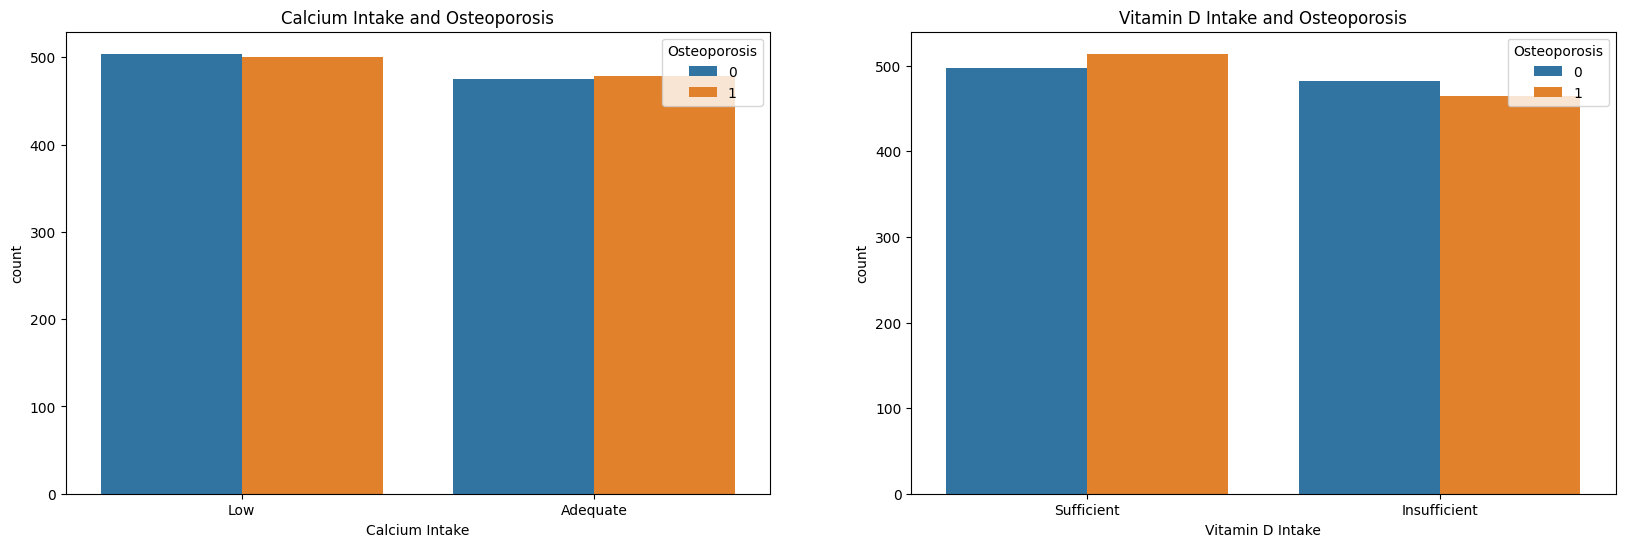

In [21]:
fig,ax =plt.subplots(1,2,figsize=(20,6))
sns.countplot(x='Calcium Intake',data = orp_data,hue='Osteoporosis',ax=ax[0]).set_title("Calcium Intake and Osteoporosis")
sns.countplot(x='Vitamin D Intake',data=orp_data, ax=ax[1],hue='Osteoporosis').set_title("Vitamin D Intake and Osteoporosis")

Nutrition and Osteoporosis are closely related. The graph shows that patients with lower calcium and vitamin D levels have a higher risk of osteoporosis than those with higher calcium and vitamin D levels. This indicates that nutrition can be a significant risk factor for osteoporosis. This highlights that our nutrition contributes in making our bones strong.

#### Physical Activity and Osteoporosis

Text(0.5, 1.0, 'Physical Activity and Osteoporosis')

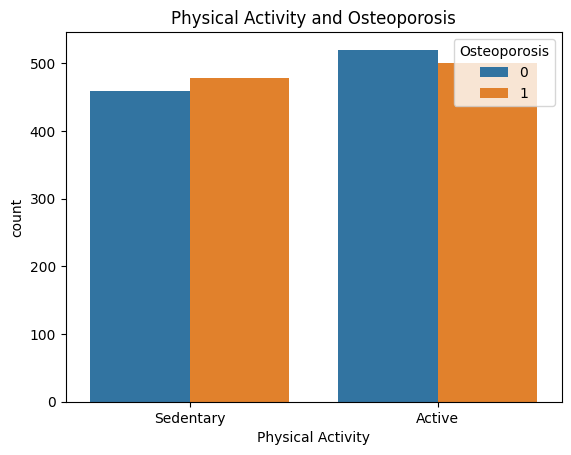

In [22]:
sns.countplot(x='Physical Activity',data=orp_data,hue='Osteoporosis').set_title('Physical Activity and Osteoporosis')

Physical Activity and Osteoporosis have a relation between them. The graph shows that patients with active physical acitve lifestyle lower risk of osteoporosis as compared to the patients with sedentary lifestyle.

In [23]:
orp_data.columns

Index(['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
       'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis'],
      dtype='object')

#### Smoking and Alcohol Consumption

Text(0.5, 1.0, 'Alcohol and Osteoporosis')

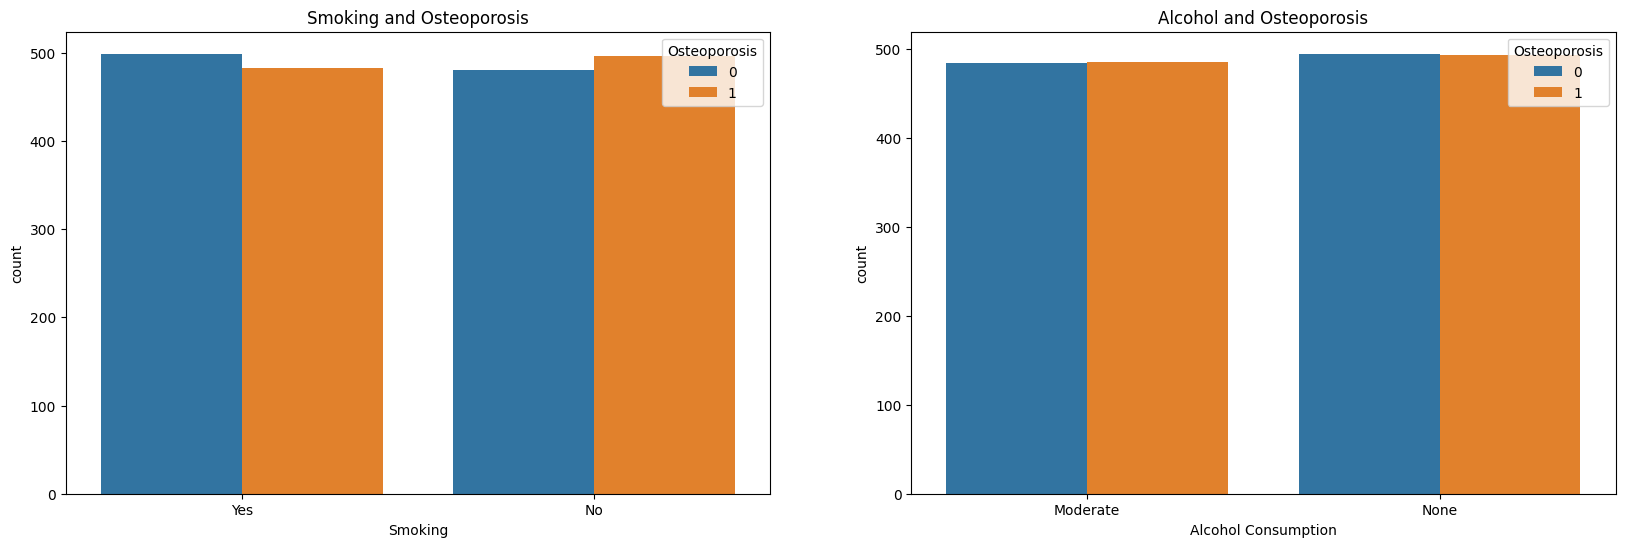

In [25]:
#smoking and alcohol consumption
fig,ax = plt.subplots(1,2,figsize=(20,6))
sns.countplot(x='Smoking',data=orp_data,ax=ax[0],hue='Osteoporosis').set_title('Smoking and Osteoporosis')
sns.countplot(x='Alcohol Consumption',data=orp_data,ax=ax[1],hue='Osteoporosis').set_title('Alcohol and Osteoporosis')

Smoking and Alcohol Consumption are one of those factors that could have adverse effect on a patients health. Here, the graph shows that patients who smoke and consume alcohol does not relate to the risk of osteoporosis. This indicates that smoking and alcohol consumption are not significant risk factors for osteoporosis.

#### Medical Conditions and Medications and Osteoporosis

Text(0.5, 1.0, 'Medications and Osteoporosis')

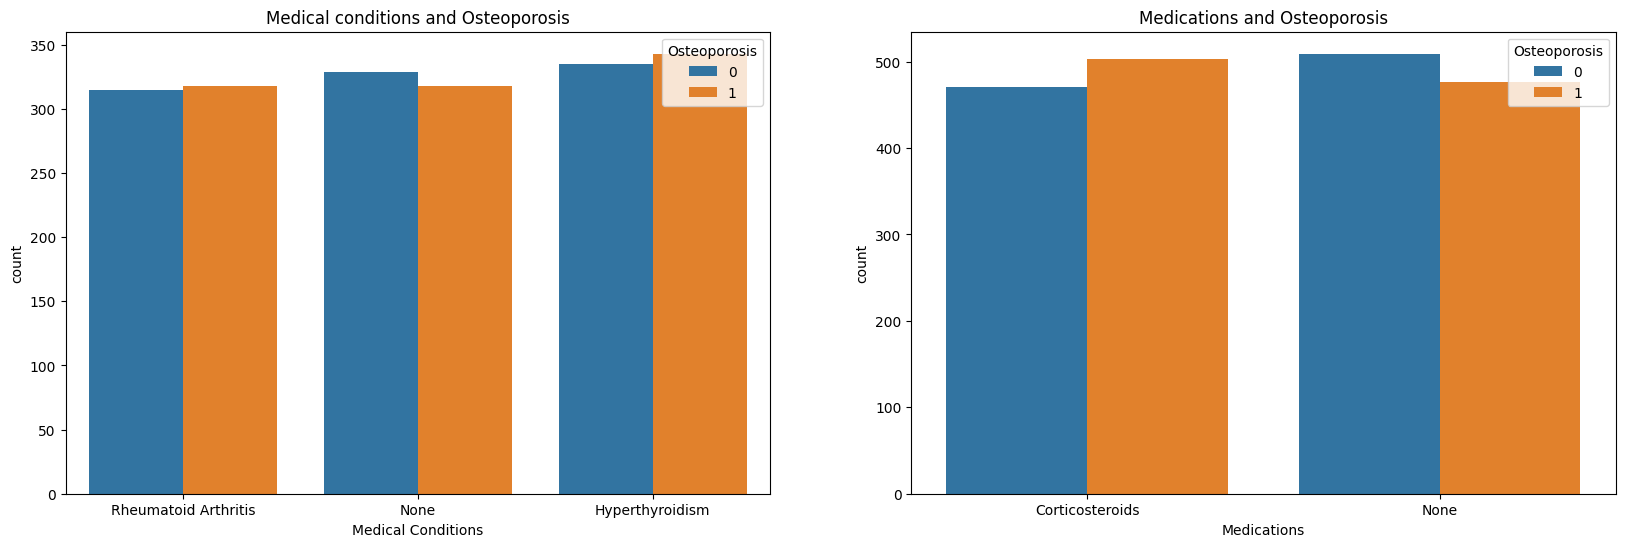

In [26]:
fig, ax = plt.subplots(1,2,figsize=(20,6))
sns.countplot(x='Medical Conditions',data=orp_data,ax=ax[0],hue='Osteoporosis').set_title('Medical conditions and Osteoporosis')
sns.countplot(x='Medications',data=orp_data,ax=ax[1],hue='Osteoporosis').set_title('Medications and Osteoporosis')

#### Prior Fractures and Osteoporosis

Text(0.5, 1.0, 'Prior Fractures and Osteoporosis')

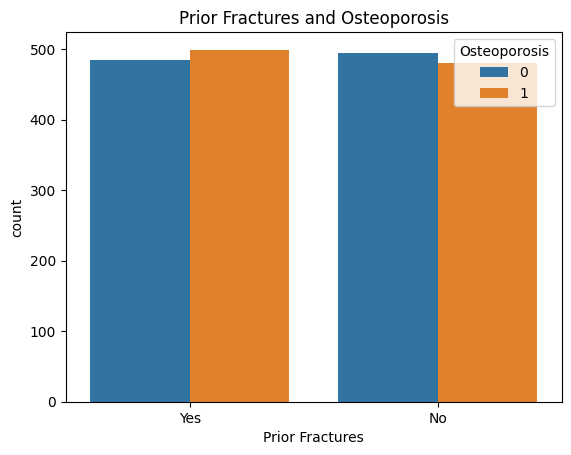

In [28]:
sns.countplot(x='Prior Fractures',data=orp_data,hue='Osteoporosis').set_title('Prior Fractures and Osteoporosis')

This graph shows the relation between the prior incident of fractures and risk of osteoporosis and from the graph it is clear that there is no concrete relationship between the prior incident of fractures and risk of osteoporosis.

### Data preprocessing part - 2

##### Label Encoding the categorical variables

In [31]:
# columns of label encoding
cols = orp_data.select_dtypes(include='object').columns

#Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cols:
    orp_data[col] = le.fit_transform(orp_data[col])
    print(col,":",orp_data[col].unique())

Gender : [0 1]
Hormonal Changes : [0 1]
Family History : [1 0]
Race/Ethnicity : [1 2 0]
Body Weight : [1 0]
Calcium Intake : [1 0]
Vitamin D Intake : [1 0]
Physical Activity : [1 0]
Smoking : [1 0]
Alcohol Consumption : [0 1]
Medical Conditions : [2 1 0]
Medications : [0 1]
Prior Fractures : [1 0]


### Correlation Matrix Heatmap

<Axes: >

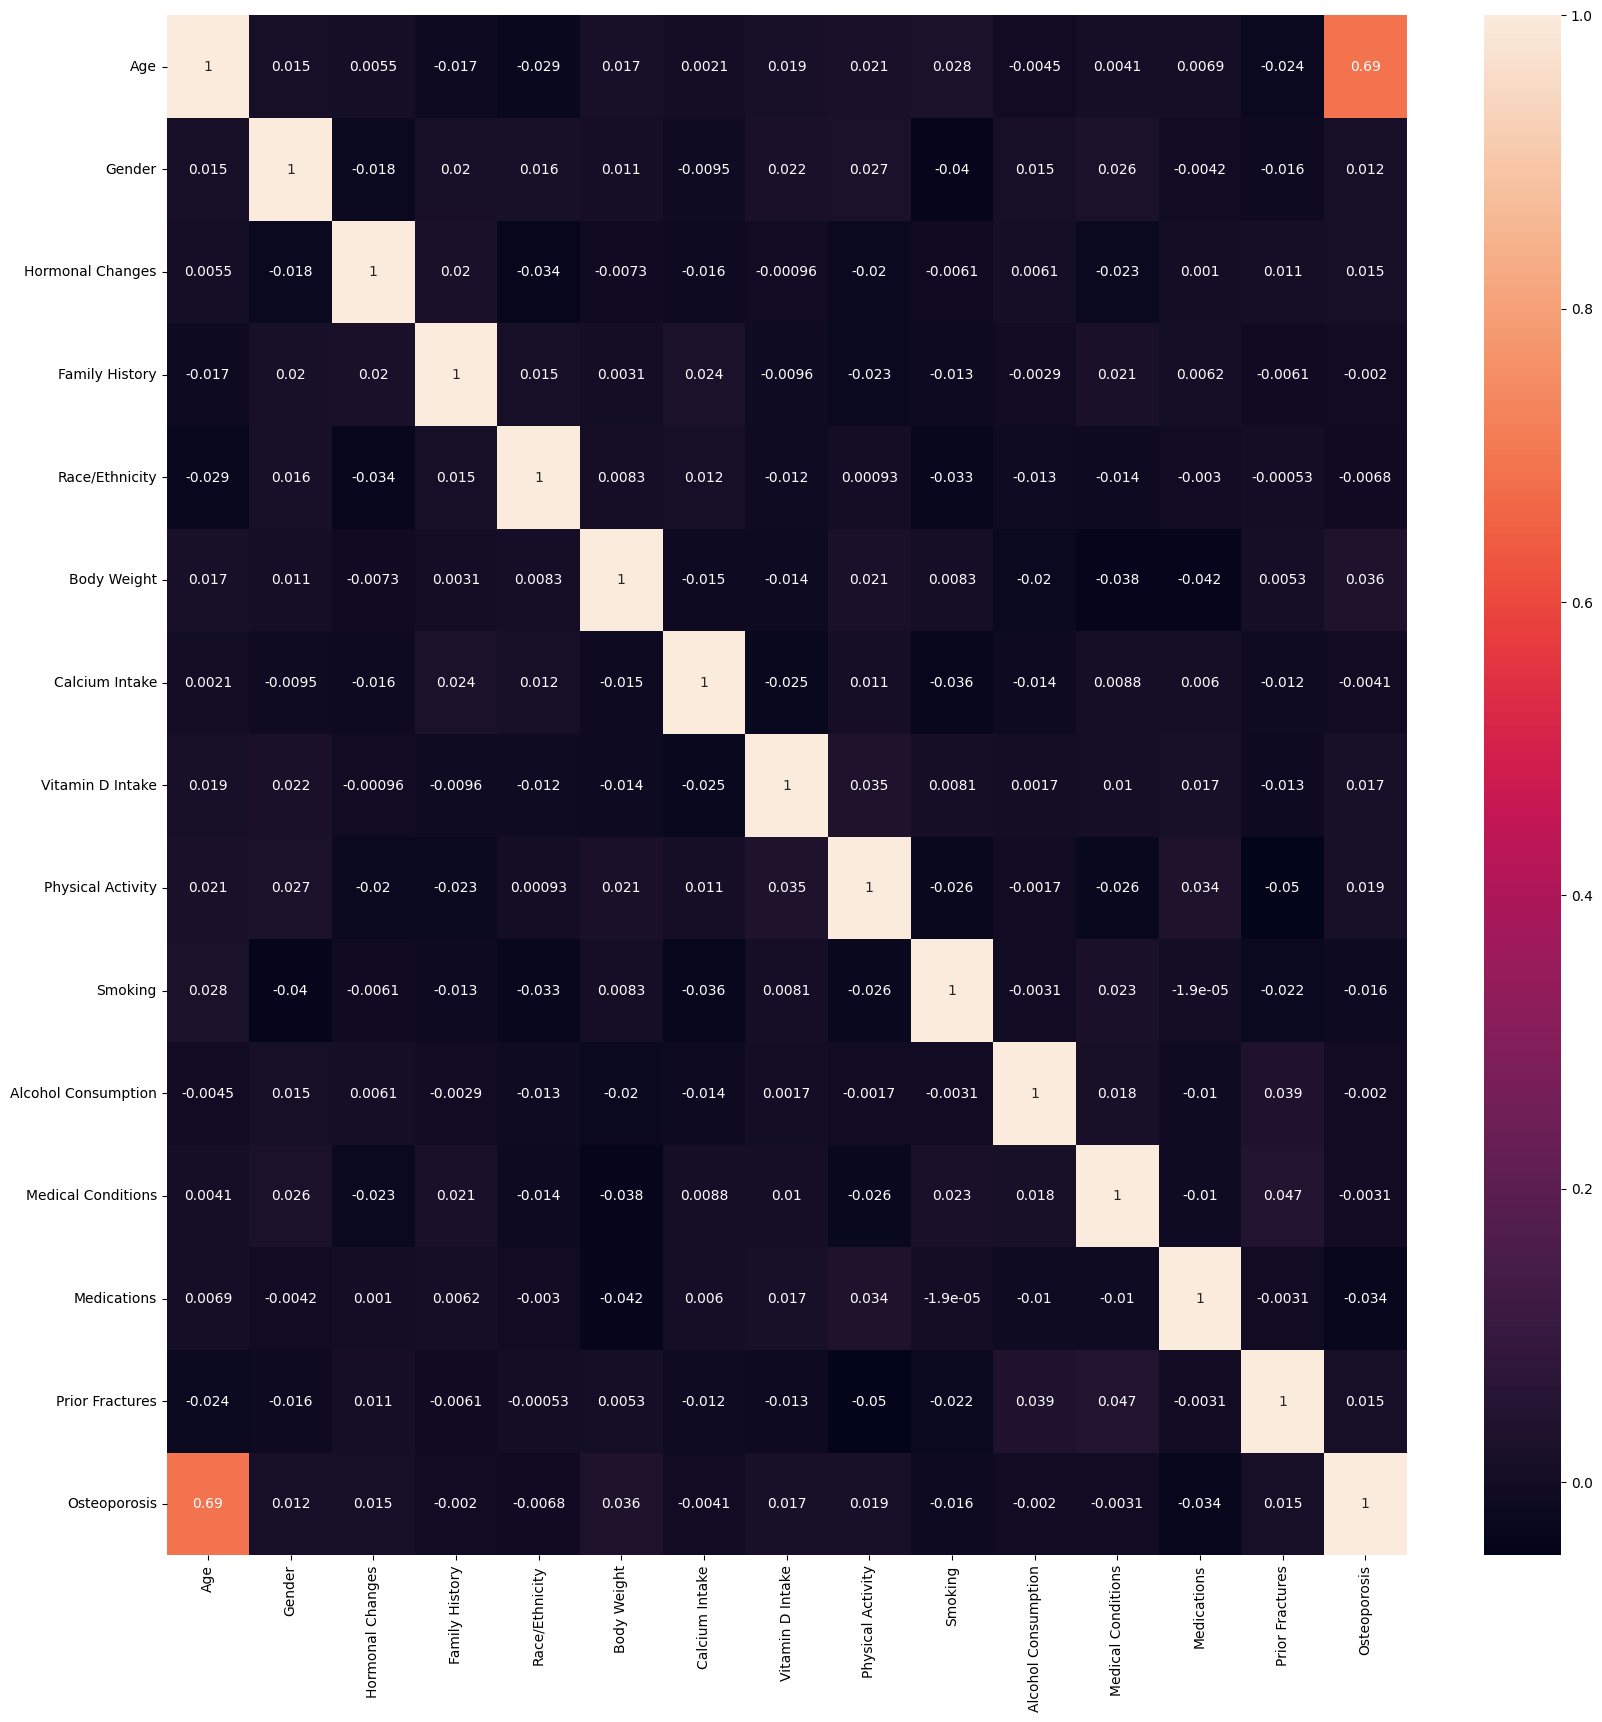

In [36]:
corr=orp_data.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr,annot=True)

### Save the Label encoded dataset file

In [39]:
orp_data.to_csv(r'C:\Users\shobi\Documents\GitHub\Osteoporosis-Risk-Prediction\data\osteoporosis_encoded.csv',index=False)
print("CSV saved successfully")

CSV saved successfully
